In [1]:
from pathlib import Path
from collections import Counter

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_DIR = Path("../data/raw/ppe_detection")

DATA_YAML = DATASET_DIR / "data.yaml"

with open(DATA_YAML, "r") as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config["names"]

print("Classes:")

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id} -> {class_name}")

Classes:
0 -> helmet
1 -> mask
2 -> vest


In [3]:
splits = {
    "train": DATASET_DIR / "train",
    "valid": DATASET_DIR / "valid",
    "test": DATASET_DIR / "test"
}

image_counts = {}

for split, split_dir in splits.items():

    image_dir = split_dir / "images"

    images = [
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    image_counts[split] = len(images)

image_counts

{'train': 629, 'valid': 15, 'test': 6}

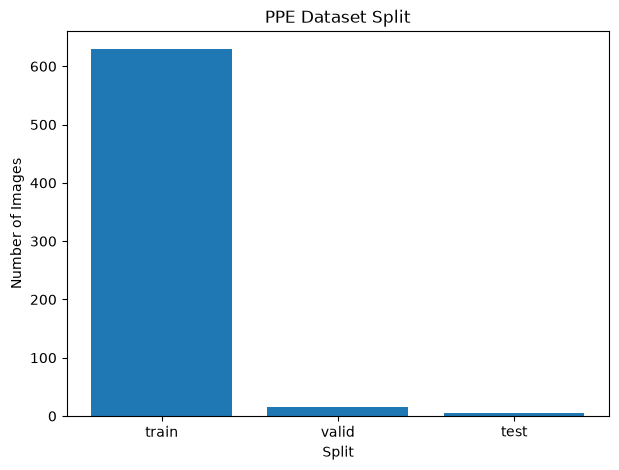

In [4]:
plt.figure(figsize=(7, 5))

plt.bar(
    image_counts.keys(),
    image_counts.values()
)

plt.title("PPE Dataset Split")
plt.xlabel("Split")
plt.ylabel("Number of Images")

plt.show()

In [5]:
bbox_data = []

for split, split_dir in splits.items():

    label_dir = split_dir / "labels"

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id, xc, yc, w, h = map(
                    float,
                    parts
                )

                bbox_data.append({
                    "split": split,
                    "image": label_file.stem,
                    "class_id": int(class_id),
                    "class": CLASS_NAMES[int(class_id)],
                    "x_center": xc,
                    "y_center": yc,
                    "width": w,
                    "height": h
                })

bbox_df = pd.DataFrame(bbox_data)

print("Total annotated objects:", len(bbox_df))

bbox_df.head()

Total annotated objects: 1746


,split,image,class_id,class,x_center,y_center,width,height
0,train,00011_jpg.rf.a1188b9d03fcbb0aebac8240eec8e7a6,2,vest,0.676562,0.469531,0.223438,0.437500
1,train,00014_jpg.rf.85a67b19da8ec5c45d97f90bd0153c0e,2,vest,0.532031,0.711719,0.304688,0.543750
2,train,00014_jpg.rf.85a67b19da8ec5c45d97f90bd0153c0e,0,helmet,0.531250,0.192188,0.167187,0.179688
3,train,00014_jpg.rf.85a67b19da8ec5c45d97f90bd0153c0e,2,vest,0.315625,0.515625,0.087500,0.184375
4,train,00014_jpg.rf.f50d3041bcfbd497ed7a265b87cd6f56,2,vest,0.532031,0.711719,0.304688,0.543750


In [6]:
class_distribution = (
    bbox_df["class"]
    .value_counts()
)

print(class_distribution)

class
vest      764
helmet    634
mask      348
Name: count, dtype: int64


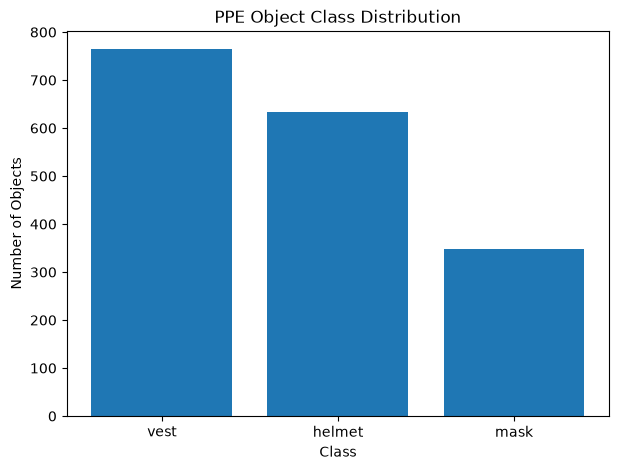

In [7]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution.index,
    class_distribution.values
)

plt.title("PPE Object Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")

plt.show()

In [8]:
split_class_distribution = pd.crosstab(
    bbox_df["split"],
    bbox_df["class"]
)

print(split_class_distribution)

class  helmet  mask  vest
split                    
test        9     5     9
train     604   329   741
valid      21    14    14


In [9]:
objects_per_image = (
    bbox_df
    .groupby(["split", "image"])
    .size()
    .reset_index(name="object_count")
)

objects_per_image.head()

,split,image,object_count
0,test,202234-7-_jpg.rf.76126ad26c1fda6bdf4cfa6d94d7bda5,2
1,test,48_jpg.rf.201a39df2571e6e9d1d556248750a46e,2
2,test,Screenshot-2024-09-24-132620_png.rf.77ad4a1081...,13
3,test,image_184_jpg.rf.632cdfb1fa5792106dcf011f7cdd1b48,3
4,test,img17_png_jpg.rf.c4b231d07e3a84b1707728edfb8dc9fb,1


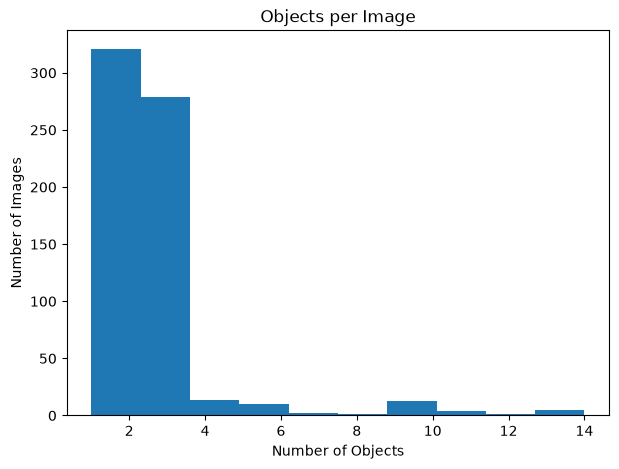

In [10]:
plt.figure(figsize=(7, 5))

plt.hist(
    objects_per_image["object_count"],
    bins=10
)

plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")

plt.show()

In [11]:
bbox_df[
    ["width", "height"]
].describe()

,width,height
count,1746.000000,1746.000000
mean,0.172715,0.190932
std,0.130613,0.166241
min,0.002047,0.001344
25%,0.082812,0.066953
50%,0.150000,0.127344
75%,0.218750,0.265625
max,0.956250,1.000000


In [14]:
bbox_df["area"] = (
    bbox_df["width"] *
    bbox_df["height"]
)

bbox_df["aspect_ratio"] = (
    bbox_df["width"] /
    bbox_df["height"]
)

bbox_df[
    ["width", "height", "area", "aspect_ratio"]
].describe()

,width,height,area,aspect_ratio
count,1746.000000,1746.000000,1746.000000,1746.000000
mean,0.172715,0.190932,0.048978,1.198095
std,0.130613,0.166241,0.095960,0.671003
min,0.002047,0.001344,0.000003,0.079239
25%,0.082812,0.066953,0.005906,0.634966
50%,0.150000,0.127344,0.018102,1.051282
75%,0.218750,0.265625,0.054794,1.681364
max,0.956250,1.000000,0.956250,3.152590


In [15]:
bbox_df.groupby(
    "class"
)[
    ["width", "height", "area"]
].mean()

,width,height,area
class,,,
helmet,0.149678,0.110321,0.021463
mask,0.080895,0.065892,0.006755
vest,0.233657,0.314782,0.091042


In [16]:
invalid_boxes = bbox_df[
    (bbox_df["x_center"] < 0) |
    (bbox_df["x_center"] > 1) |
    (bbox_df["y_center"] < 0) |
    (bbox_df["y_center"] > 1) |
    (bbox_df["width"] <= 0) |
    (bbox_df["height"] <= 0) |
    (bbox_df["width"] > 1) |
    (bbox_df["height"] > 1)
]

print(
    "Invalid bounding boxes:",
    len(invalid_boxes)
)

Invalid bounding boxes: 0


In [17]:
for split, split_dir in splits.items():

    image_dir = split_dir / "images"
    label_dir = split_dir / "labels"

    image_stems = {
        p.stem
        for p in image_dir.iterdir()
        if p.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    }

    label_stems = {
        p.stem
        for p in label_dir.glob("*.txt")
    }

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print(f"\n{split.upper()}")

    print(
        "Images without labels:",
        len(missing_labels)
    )

    print(
        "Labels without images:",
        len(missing_images)
    )


TRAIN
Images without labels: 0
Labels without images: 0

VALID
Images without labels: 0
Labels without images: 0

TEST
Images without labels: 0
Labels without images: 0


In [18]:
image_info = []

for split, split_dir in splits.items():

    image_dir = split_dir / "images"

    for image_path in image_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        image = cv2.imread(
            str(image_path)
        )

        if image is None:
            continue

        height, width, channels = (
            image.shape
        )

        image_info.append({
            "split": split,
            "image": image_path.name,
            "width": width,
            "height": height,
            "channels": channels
        })

image_df = pd.DataFrame(image_info)

image_df.describe()

,width,height,channels
count,650.000000,650.000000,650.0
mean,654.023077,643.916923,3.0
std,125.375803,93.560339,0.0
min,416.000000,413.000000,3.0
25%,640.000000,640.000000,3.0
50%,640.000000,640.000000,3.0
75%,640.000000,640.000000,3.0
max,2048.000000,2045.000000,3.0


In [19]:
corrupted = []

for split, split_dir in splits.items():

    image_dir = split_dir / "images"

    for image_path in image_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        image = cv2.imread(
            str(image_path)
        )

        if image is None:

            corrupted.append(
                str(image_path)
            )

print(
    "Corrupted images:",
    len(corrupted)
)

Corrupted images: 0


In [20]:
def show_annotation(
    image_path,
    label_path
):

    image = cv2.imread(
        str(image_path)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width = image.shape[:2]

    with open(label_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id, xc, yc, w, h = map(
                float,
                parts
            )

            xc *= width
            yc *= height
            w *= width
            h *= height

            x1 = int(xc - w / 2)
            y1 = int(yc - h / 2)
            x2 = int(xc + w / 2)
            y2 = int(yc + h / 2)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                CLASS_NAMES[int(class_id)],
                (x1, max(0, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.figure(figsize=(12, 8))

    plt.imshow(image)

    plt.axis("off")

    plt.show()

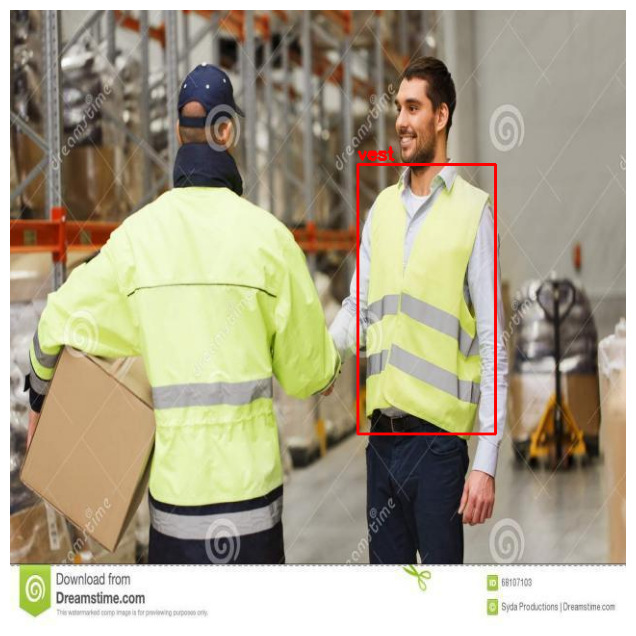

In [21]:
image_dir = (
    DATASET_DIR /
    "train" /
    "images"
)

label_dir = (
    DATASET_DIR /
    "train" /
    "labels"
)

image_path = next(
    image_dir.iterdir()
)

label_path = (
    label_dir /
    f"{image_path.stem}.txt"
)

show_annotation(
    image_path,
    label_path
)